<a href="https://colab.research.google.com/github/Adelgrin/inteligencia_artificial/blob/master/labs/notebooks/lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Desafio 1

In [1]:
import numpy as np
import random
from tqdm import tqdm

In [2]:
import numpy as np
import random
from tqdm import tqdm

class AlgoritmoGenetico:
  def __init__(self, tamanho_populacao, taxa_mutacao, tamanho_elitismo=2):
    self.tamanho_populacao = tamanho_populacao
    self.taxa_mutacao = taxa_mutacao
    self.tamanho_elitismo = tamanho_elitismo
    self.populacao = []
    # Métodos que DEVEM ser sobrescritos pelas classes filhas
  def gerar_individuo(self):
    #raise NotImplementedError("Os alunos precisam definir como é o cromossomo!")
    return np.random.uniform(self.limite_inferior, self.limite_superior, self.dimensoes)
  def calcular_fitness(self, individuo):
    #raise NotImplementedError("Os alunos precisam definir a função de aptidão!")
    a = 20
    b = 0.2
    c = 2 * np.pi

    soma1 = np.sum(individuo**2)
    soma2 = np.sum(np.cos(c * individuo))

    termo1 = -a * np.exp(-b * np.sqrt((1/self.dimensoes) * soma1))
    termo2 = -np.exp((1/self.dimensoes) * soma2)

    valor_ackley = termo1 + termo2 + a + np.exp(1)

    return 1.0 / (valor_ackley + 1e-6)
#  def crossover(self, pai1, pai2):
#    raise NotImplementedError("Os alunos precisam definir como os pais se reproduzem!")
#  def mutacao(self, individuo):
#    raise NotImplementedError("Os alunos precisam definir a mutação para gerar diversidade!")
  def inicializar_populacao(self):
    self.populacao = [self.gerar_individuo() for _ in range(self.tamanho_populacao)]
  def selecao_roleta(self, fitness_populacao):
    soma_fitness = sum(fitness_populacao)
    if soma_fitness == 0:
      return random.choice(self.populacao)
    probabilidades = [f / soma_fitness for f in fitness_populacao]
    indice_escolhido = np.random.choice(len(self.populacao), p=probabilidades)
    return self.populacao[indice_escolhido]
  def evoluir(self, max_geracoes, objetivo_fitness=None, paciencia=None):
    self.inicializar_populacao()

    pbar = tqdm(range(max_geracoes), desc = "Evolução População", bar_format = '{bar} |  Gen {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {postfix}]')

    melhor_global = None
    melhor_fitness_global = -float('inf')
    historico = []

    for geracao in pbar:
      fitness_populacao = [self.calcular_fitness(individuo) for individuo in self.populacao]

      # Verifica se a população e fitness_populacao não estão vazias
      if not fitness_populacao:
          continue # Pula para a próxima iteração se não houver indivíduos

      melhor_indice = np.argmax(fitness_populacao)
      melhor_individuo_atual = self.populacao[melhor_indice]
      melhor_fitness_atual = fitness_populacao[melhor_indice]

      # O objetivo é maximizar o fitness (1.0 / (valor_ackley + 1e-6))
      if melhor_fitness_atual > melhor_fitness_global:
        melhor_fitness_global = melhor_fitness_atual
        melhor_global = np.copy(melhor_individuo_atual)

      pbar.set_postfix({"melhor fit:": f"{melhor_fitness_global:.2f}"})
      historico.append({'geracao' : geracao,
                        'melhor individuo' : np.copy(melhor_global),
                        'melhor fitness' : melhor_fitness_global})

      indice_elite = np.argsort(fitness_populacao)[-self.tamanho_elitismo:]
      nova_populacao = [self.populacao[i] for i in indice_elite]

      while len(nova_populacao) < self.tamanho_populacao:
        pai1 = self.selecao_roleta(fitness_populacao)
        pai2 = self.selecao_roleta(fitness_populacao)

        filho = self.crossover(pai1, pai2)
        filho = self.mutacao(filho)
        nova_populacao.append(filho)

      self.populacao = nova_populacao

    return melhor_global, melhor_fitness_global, historico

In [3]:
class EquacaoLinear(AlgoritmoGenetico):
  def __init__(self, tamanho_populacao, taxa_mutacao):
    super().__init__(tamanho_populacao, taxa_mutacao)
    self.dimensoes = 3

  def gerar_individuo(self):
    return np.random.uniform(-10,10,self.dimensoes)

  def calcular_fitness(self,individuo):
    x,y,z = individuo
    erro = abs((x+y+z) - 3.0)
    return 1.0 / (erro + 1e-6)
  def crossover(self,pai1,pai2):
    alpha = random.random()
    return alpha * pai1 + (1 - alpha) * pai2
  def mutacao(self, individuo):
    for i in range(self.dimensoes):
      if np.random.rand() < self.taxa_mutacao:
        individuo[i] += random.uniform(-0.5,0.5)
    return individuo # Adicionar esta linha
  def evoluir(self, max_geracoes, objetivo_fitness=None, paciencia=None):
    self.inicializar_populacao()

    pbar = tqdm(range(max_geracoes), desc = "Evolução População", bar_format = '{bar} |  Gen {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {postfix}]')

    melhor_global = None
    melhor_fitness_global = float('-inf') # Changed to -inf because we want to maximize fitness
    historico = []

    for geracao in pbar:
      fitness_populacao = [self.calcular_fitness(individuo) for individuo in self.populacao]

      # Verifica se a população e fitness_populacao não estão vazias
      if not fitness_populacao:
          continue # Pula para a próxima iteração se não houver indivíduos

      melhor_indice = np.argmax(fitness_populacao)
      melhor_individuo_atual = self.populacao[melhor_indice]
      melhor_fitness_atual = fitness_populacao[melhor_indice]

      # O objetivo é maximizar o fitness (1.0 / (erro + 1e-6))
      if melhor_fitness_atual > melhor_fitness_global:
        melhor_fitness_global = melhor_fitness_atual
        melhor_global = np.copy(melhor_individuo_atual)

      pbar.set_postfix({"melhor fit:": f"{melhor_fitness_global:.2f}"})
      historico.append({'geracao' : geracao,
                        'melhor individuo' : np.copy(melhor_global),
                        'melhor fitness' : melhor_fitness_global})

      indice_elite = np.argsort(fitness_populacao)[-self.tamanho_elitismo:]
      nova_populacao = [self.populacao[i] for i in indice_elite]

      while len(nova_populacao) < self.tamanho_populacao:
        pai1 = self.selecao_roleta(fitness_populacao)
        pai2 = self.selecao_roleta(fitness_populacao)

        filho = self.crossover(pai1, pai2)
        filho = self.mutacao(filho)
        nova_populacao.append(filho)

      self.populacao = nova_populacao

    return melhor_global, melhor_fitness_global, historico

In [4]:
eq = EquacaoLinear(tamanho_populacao=100, taxa_mutacao=0.1)
melhor_individuo,melhor_fitness, historico = eq.evoluir(max_geracoes=300)
x,y,z = melhor_individuo
soma_obtida = x+y+z
print(f"x = {x:.2f}")
print(f"y = {y:.2f}")
print(f"z = {z:.2f}")
print(f"soma obtida: {soma_obtida:.2f}")

██████████ |  Gen 300/300 [00:07<00:00, , melhor fit:=999980.08]

x = 1.13
y = -3.84
z = 5.71
soma obtida: 3.00


## Desafio 2

In [5]:
class Ackley(AlgoritmoGenetico):
  def __init__(self, tamanho_populacao, taxa_mutacao):
    super().__init__(tamanho_populacao, taxa_mutacao)
    self.dimensoes = 2
  def gerar_individuo(self):
    return np.random.uniform(-32.0, 32.0, self.dimensoes)
  def crossover(self,pai1,pai2):
    alpha = random.random()
    return alpha * pai1 + (1 - alpha) * pai2
  def mutacao(self, individuo):
    for i in range(self.dimensoes):
      if np.random.rand() < self.taxa_mutacao:
        individuo[i] += random.uniform(-0.5,0.5)
    return individuo # Adicionar esta linha

In [6]:
ackley_ga = Ackley(tamanho_populacao=200, taxa_mutacao=0.05)
melhor_individuo_ackley, melhor_fitness_ackley, historico_ackley = ackley_ga.evoluir(max_geracoes=500)

x_ackley, y_ackley = melhor_individuo_ackley
# Para obter o valor real da função Ackley, invertemos o fitness calculado
valor_minimo_ackley = (1.0 / melhor_fitness_ackley) - 1e-6

print(f"Melhor indivíduo para Ackley: x = {x_ackley:.4f}, y = {y_ackley:.4f}")
print(f"Valor mínimo da função Ackley: {valor_minimo_ackley:.4f}")

██████████ |  Gen 500/500 [00:22<00:00, , melhor fit:=996620.11]

Melhor indivíduo para Ackley: x = -0.0000, y = -0.0000
Valor mínimo da função Ackley: 0.0000


## Desafio 3

In [7]:
class CaixeiroViajante(AlgoritmoGenetico):
  def __init__(self, coordenadas_cidades, tamanho_populacao, taxa_mutacao):
    super().__init__(tamanho_populacao, taxa_mutacao)
    self.cidades = coordenadas_cidades
    self.num_cidades = len(coordenadas_cidades)
    # O indivíduo agora será uma permutação dos índices das cidades, não um vetor de floats
    self.dimensoes = self.num_cidades # O número de "dimensões" é o número de cidades a visitar

  def gerar_individuo(self):
    # Um indivíduo é uma permutação aleatória dos índices das cidades
    return np.random.permutation(self.num_cidades)

  # Função auxiliar para calcular a distância euclidiana entre duas cidades
  def _calcular_distancia(self, cidade_idx1, cidade_idx2):
    coord1 = self.cidades[cidade_idx1]
    coord2 = self.cidades[cidade_idx2]
    return np.linalg.norm(coord1 - coord2)

  def calcular_fitness(self, individuo):
    distancia_total = 0
    for i in range(self.num_cidades):
      cidade_atual_idx = individuo[i]
      cidade_proxima_idx = individuo[(i + 1) % self.num_cidades] # Volta para a primeira cidade no final
      distancia_total += self._calcular_distancia(cidade_atual_idx, cidade_proxima_idx)

    # Queremos minimizar a distância total, então o fitness é o inverso da distância
    return 1.0 / (distancia_total + 1e-6) # Adiciona um pequeno valor para evitar divisão por zero

  def crossover(self, pai1, pai2):
    # Crossover PMX (Partially Mapped Crossover) - adequado para permutações
    tamanho = len(pai1)
    filho = np.zeros(tamanho, dtype=int) - 1 # Inicializa o filho com -1 (cidades não definidas)

    # Escolhe dois pontos de corte aleatórios
    ponto_corte1, ponto_corte2 = sorted(random.sample(range(tamanho), 2))

    # Copia o segmento do pai1 para o filho
    filho[ponto_corte1:ponto_corte2] = pai1[ponto_corte1:ponto_corte2]

    # Cria o mapeamento para o segmento do pai2
    for i in range(ponto_corte1, ponto_corte2):
      gene1 = pai1[i]
      gene2 = pai2[i]
      if gene2 not in filho:
        # Encontra a posição onde o gene2 deveria ir
        pos = i
        while filho[pos] != -1:
          pos = np.where(pai1 == pai2[pos])[0][0]
        filho[pos] = gene2

    # Preenche os genes restantes do pai2
    for i in range(tamanho):
      if filho[i] == -1:
        if pai2[i] not in filho:
          filho[i] = pai2[i]
        else:
          # Lida com duplicatas: encontra o valor mapeado
          val = pai2[i]
          while val in pai1[ponto_corte1:ponto_corte2]:
            idx = np.where(pai1 == val)[0][0]
            val = pai2[idx]
          filho[i] = val

    return filho # O PMX geralmente gera um único filho, ou dois se implementado simetricamente

  def mutacao(self, individuo):
    # Mutação de troca (swap mutation) - adequado para permutações
    individuo_mutado = np.copy(individuo)
    if np.random.rand() < self.taxa_mutacao:
      idx1, idx2 = random.sample(range(self.num_cidades), 2)
      individuo_mutado[idx1], individuo_mutado[idx2] = individuo_mutado[idx2], individuo_mutado[idx1]
    return individuo_mutado

In [10]:
class CaixeiroViajante(AlgoritmoGenetico):

    def __init__(self, coordenadas_cidades, tamanho_populacao, taxa_mutacao):
        super().__init__(tamanho_populacao, taxa_mutacao)
        self.cidades = coordenadas_cidades
        self.num_cidades = len(coordenadas_cidades)
        self.dimensoes = self.num_cidades

    # indivíduo = permutação das cidades
    def gerar_individuo(self):
        return np.random.permutation(self.num_cidades)

    # distância total da rota
    def distancia_rota(self, individuo):
        distancia = 0

        for i in range(len(individuo) - 1):
            c1 = self.cidades[individuo[i]]
            c2 = self.cidades[individuo[i+1]]
            distancia += np.linalg.norm(c1 - c2)

        # voltar para cidade inicial
        c1 = self.cidades[individuo[-1]]
        c2 = self.cidades[individuo[0]]
        distancia += np.linalg.norm(c1 - c2)

        return distancia

    def calcular_fitness(self, individuo):
        distancia = self.distancia_rota(individuo)
        return 1.0 / (distancia + 1e-6)

    # crossover OX simplificado
    def crossover(self, pai1, pai2):

        corte1, corte2 = sorted(random.sample(range(self.num_cidades), 2))

        filho = [-1] * self.num_cidades
        filho[corte1:corte2] = pai1[corte1:corte2]

        pos = corte2

        for cidade in pai2:
            if cidade not in filho:
                if pos >= self.num_cidades:
                    pos = 0
                filho[pos] = cidade
                pos += 1

        return np.array(filho)

    # mutação swap
    def mutacao(self, individuo):

        if random.random() < self.taxa_mutacao:

            i, j = random.sample(range(self.num_cidades), 2)
            individuo[i], individuo[j] = individuo[j], individuo[i]

        return individuo

In [11]:
# Caso de teste
cidades_tsp = np.array([
[2.0, 99.0], [4.0, 50.0], [7.0, 64.0], [13.0,
40.0], [18.0, 54.0],
[18.0, 40.0], [22.0, 60.0], [24.0, 42.0], [25.0,
62.0], [25.0, 38.0],
[37.0, 84.0], [41.0, 94.0], [41.0, 26.0], [44.0,
35.0], [45.0, 21.0],
[54.0, 67.0], [54.0, 62.0], [58.0, 69.0], [58.0,
35.0], [62.0, 32.0],
[64.0, 60.0], [68.0, 58.0], [71.0, 71.0], [71.0,
44.0], [74.0, 78.0],
[82.0, 7.0],
[83.0, 69.0], [83.0, 46.0], [87.0,
76.0], [91.0, 38.0]
])

In [12]:
tsp_ga = CaixeiroViajante(coordenadas_cidades=cidades_tsp, tamanho_populacao=500, taxa_mutacao=0.05)
melhor_rota_indices, melhor_fitness_tsp, historico_tsp = tsp_ga.evoluir(max_geracoes=1000)

# Para obter a distância real, invertemos o fitness
distancia_minima_tsp = (1.0 / melhor_fitness_tsp) - 1e-6

print(f"Melhor rota encontrada (índices das cidades): {melhor_rota_indices}")
print(f"Distância mínima total: {distancia_minima_tsp:.2f}")

# Opcional: Para visualizar as coordenadas da rota
print("Coordenadas da melhor rota:")
for idx in melhor_rota_indices:
    print(f"  {cidades_tsp[idx]}")

██████████ |  Gen 1000/1000 [04:26<00:00, , melhor fit:=0.00]

Melhor rota encontrada (índices das cidades): [ 5  9  8 10 16 22 24 28 26 17 15 11  0  2  6  4  1  3 19 29 27 23 21 20
 18 25 14 12 13  7]
Distância mínima total: 584.16
Coordenadas da melhor rota:
  [18. 40.]
  [25. 38.]
  [25. 62.]
  [37. 84.]
  [54. 62.]
  [71. 71.]
  [74. 78.]
  [87. 76.]
  [83. 69.]
  [58. 69.]
  [54. 67.]
  [41. 94.]
  [ 2. 99.]
  [ 7. 64.]
  [22. 60.]
  [18. 54.]
  [ 4. 50.]
  [13. 40.]
  [62. 32.]
  [91. 38.]
  [83. 46.]
  [71. 44.]
  [68. 58.]
  [64. 60.]
  [58. 35.]
  [82.  7.]
  [45. 21.]
  [41. 26.]
  [44. 35.]
  [24. 42.]


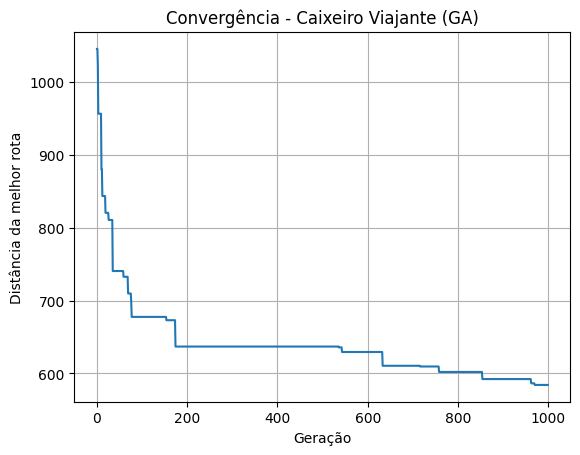

In [13]:
import matplotlib.pyplot as plt

geracoes = [h['geracao'] for h in historico_tsp]
fitness = [h['melhor fitness'] for h in historico_tsp]

# converter fitness para distância
distancias = [(1/f) - 1e-6 for f in fitness]

plt.figure()
plt.plot(geracoes, distancias)
plt.xlabel("Geração")
plt.ylabel("Distância da melhor rota")
plt.title("Convergência - Caixeiro Viajante (GA)")
plt.grid(True)
plt.show()